In [1]:
# Install required packages
%pip install diffusers transformers accelerate torch torchvision torchaudio


In [2]:
import torch
from diffusers import StableDiffusionXLPipeline
import gc

# Clear any cached memory from previous runs
torch.cuda.empty_cache()
gc.collect()

# Load the stable diffusion XL base 1.0 model
# pipe = StableDiffusionXLPipeline.from_pretrained(
#     "stabilityai/stable-diffusion-xl-base-1.0",
#     torch_dtype=torch.float16,
#     variant="fp16",
#     use_safetensors=True
# )

pipe = StableDiffusionXLPipeline.from_single_file(
    "https://huggingface.co/wangkanai/sdxl-fp8/blob/main/checkpoints/sdxl/sdxl-base.safetensors",
    torch_dtype=torch.float16, # Keep pipeline execution in fp16
)
pipe.to("cuda")

# Enable memory optimizations instead of loading everything onto GPU VRAM at once
# pipe.enable_model_cpu_offload() # Dynamically offloads model layers to CPU to free VRAM
# pipe.enable_vae_slicing()       # Decodes images in slices to save VRAM

print("Model loaded with memory optimizations (CPU offload & VAE slicing)")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


checkpoints/sdxl/sdxl-base.safetensors:   0%|          | 0.00/6.94G [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Model loaded with memory optimizations (CPU offload & VAE slicing)


Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']


Generating image with prompt: 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'


Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


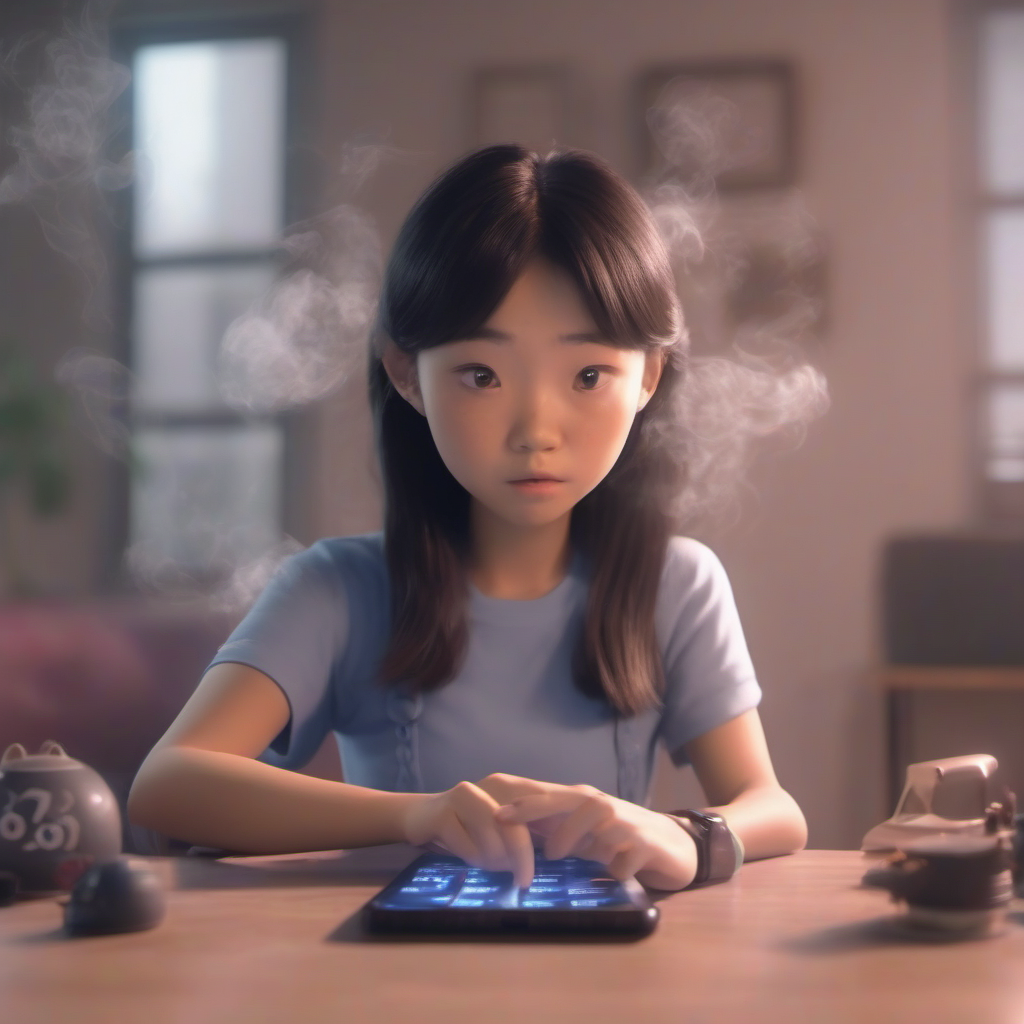

In [3]:
# Generate an image programmatically
from copy import Error

prompt = 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'
negative_prompt = ""

print(f"Generating image with prompt: '{prompt}'")
image = pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=25).images[0]

# Display the image
image

In [ ]:
# !pip install optimum-quanto

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.3 MB/s eta 0:00:00


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality l

Generating image with prompt: 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'


  0%|          | 0/20 [00:00<?, ?it/s]

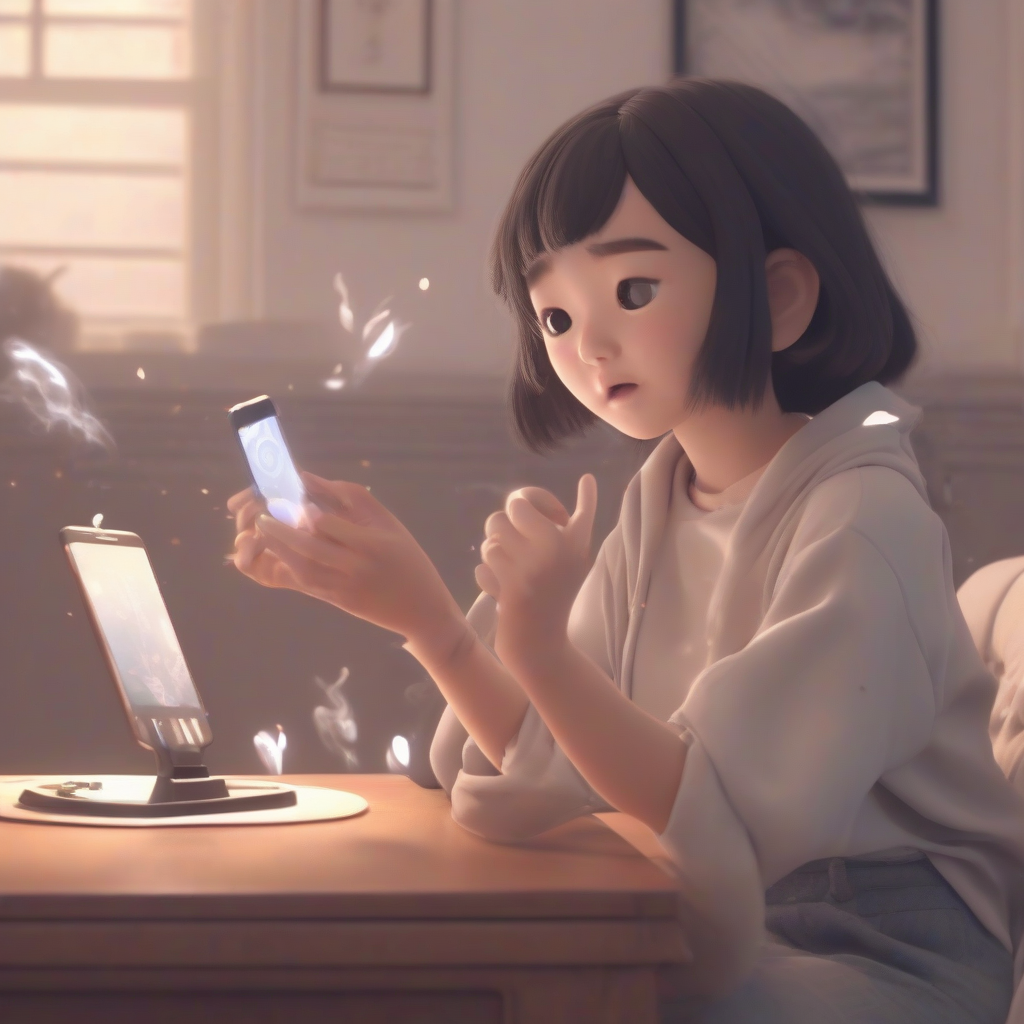

In [ ]:
# Generate an image programmatically
from copy import Error
import torch
import gc

# Free up reserved unused memory right before generating
gc.collect()
torch.cuda.empty_cache()

prompt = 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'
negative_prompt = ""

print(f"Generating image with prompt: '{prompt}'")
image = pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=20).images[0]

# Display the image
image

In [ ]:
!pip -q install pyngrok

In [7]:
from pyngrok import ngrok



In [4]:
# Cell 1: install deps
!pip -q install fastapi uvicorn pyngrok diffusers transformers accelerate torch pillow

In [5]:
from fastapi import FastAPI, Query
from fastapi.responses import StreamingResponse, JSONResponse
from io import BytesIO
import zipfile
import io
import gc
import torch

app = FastAPI(title="Colab Image API")

@app.get("/")
def health():
    return {"status": "ok", "message": "API is running"}

# @app.get("/generate-image")
# def generate_image(prompt: str = Query(..., min_length=3), steps: int = 20):
#     try:
#         # optional cleanup before generation
#         gc.collect()
#         torch.cuda.empty_cache()

#         image = pipe(
#             prompt=prompt,
#             negative_prompt="",
#             num_inference_steps=steps
#         ).images[0]

#         buf = BytesIO()
#         image.save(buf, format="PNG")
#         buf.seek(0)
#         return StreamingResponse(buf, media_type="image/png")
#     except Exception as e:
#         return JSONResponse(status_code=500, content={"error": str(e)})

@app.get("/generate-image")
def generate_image_zip(prompt: str = Query(..., min_length=3), steps: int = 20):
    try:
        # optional cleanup before generation
        gc.collect()
        torch.cuda.empty_cache()

        image = pipe(
            prompt=prompt,
            negative_prompt="",
            num_inference_steps=steps
        ).images[0]

        # Create an in-memory zip file
        zip_buffer = io.BytesIO()
        with zipfile.ZipFile(zip_buffer, 'w', zipfile.ZIP_DEFLATED) as zf:
            # Save image to a BytesIO object first
            image_buffer = BytesIO()
            image.save(image_buffer, format="PNG")
            image_buffer.seek(0)
            # Add image to zip file
            zf.writestr("generated_image.png", image_buffer.getvalue())

        zip_buffer.seek(0)
        return StreamingResponse(
            zip_buffer,
            media_type="application/zip",
            headers={
                "Content-Disposition": "attachment; filename=generated_image.zip",
                "Content-Type": "application/zip"
            }
        )
    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})

In [8]:
# Cell 4: expose API publicly from Colab
from pyngrok import ngrok
import threading
import uvicorn

# add your ngrok token once
ngrok.set_auth_token("2jgskLRiOe7GhBcW8GY1KA7rck6_2paMPJxXTQDagpfnfjdDd")
def run_api():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_api, daemon=True)
thread.start()

public_url = ngrok.connect(8000)
print("Public API URL:", public_url)
print("Try:", f"{public_url}/generate-image?prompt=a%20cute%20robot%20in%20a%20forest")

INFO:     Started server process [644]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


Public API URL: NgrokTunnel: "https://4b3a-35-231-5-213.ngrok-free.app" -> "http://localhost:8000"
Try: NgrokTunnel: "https://4b3a-35-231-5-213.ngrok-free.app" -> "http://localhost:8000"/generate-image?prompt=a%20cute%20robot%20in%20a%20forest


In [ ]:
# from pyngrok import ngrok

# # Disconnect all active ngrok tunnels and kill all ngrok processes
# print("Killing all active ngrok processes...")
# ngrok.kill()
# print("All ngrok processes killed.")

After executing the above cell, you should be able to run the FastAPI app and ngrok connection again without the 'address already in use' or 'PyngrokNgrokHTTPError' issues related to tunnel limits. Please restart the runtime or re-run the relevant cells (FastAPI app definition and ngrok connection) to re-establish the service.